scikit learn
tensorflow


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)
After Reshape: (60000, 28, 28, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9600 - loss: 0.1316 - val_accuracy: 0.9838 - val_loss: 0.0515
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9868 - loss: 0.0432 - val_accuracy: 0.9869 - val_loss: 0.0384
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9905 - loss: 0.0307 - val_accuracy: 0.9901 - val_loss: 0.0324
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - accuracy: 0.9931 - loss: 0.0213 - val_accuracy: 0.9911 - val_loss: 0.0271
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9948 - loss: 0.0154 - val_accuracy: 0.9910 - val_loss: 0.0306
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9910 - loss: 0.0306

Test Accuracy: 0.9909999966621399


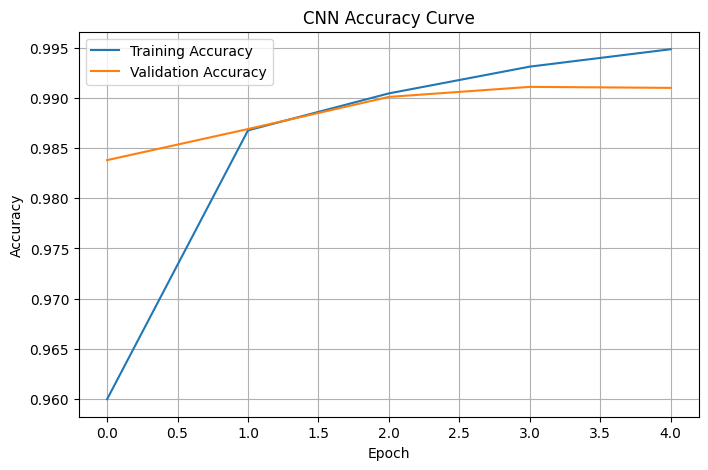

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Predicted Digit : 7
Actual Digit    : 7


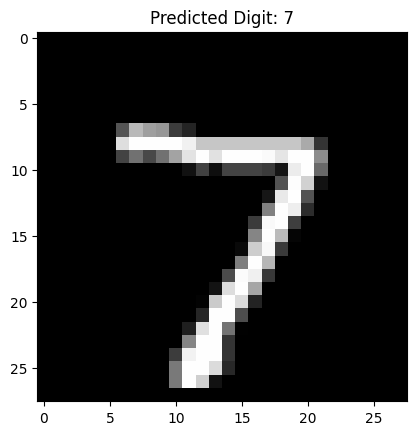

In [ ]:
# ==========================================
# HANDWRITTEN DIGIT RECOGNITION USING CNN
# Dataset: MNIST
# Digits: 0 to 9
# ==========================================

# Import TensorFlow for Deep Learning
import tensorflow as tf

# Import required CNN layers
from tensorflow.keras import layers, models

# Import Matplotlib for plotting graphs
import matplotlib.pyplot as plt


# ==========================================
# STEP 1 : LOAD DATASET
# ==========================================

# x_train -> Training Images
# y_train -> Training Labels

# x_test -> Test Images
# y_test -> Test Labels

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)


# ==========================================
# STEP 2 : NORMALIZE PIXEL VALUES
# ==========================================

# Original pixel values range:
# 0 to 255

# Convert them into:
# 0 to 1

# Helps CNN learn faster

x_train = x_train / 255.0
x_test = x_test / 255.0


# ==========================================
# STEP 3 : RESHAPE IMAGES
# ==========================================

# CNN expects:
# (Height, Width, Channel)

# Current:
# (28,28)

# Required:
# (28,28,1)

# 1 indicates grayscale image

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("After Reshape:", x_train.shape)


# ==========================================
# STEP 4 : BUILD CNN MODEL
# ==========================================

# Sequential means layer-by-layer model

model = models.Sequential()


# ==========================================
# FIRST CONVOLUTION LAYER
# ==========================================

# 32 Filters
# Filter Size = 3x3

# Learns:
# Edges
# Lines
# Curves

model.add(
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    )
)


# ==========================================
# FIRST MAX POOLING
# ==========================================

# Reduces image size
# Keeps important features

model.add(
    layers.MaxPooling2D(
        pool_size=(2, 2)
    )
)


# ==========================================
# SECOND CONVOLUTION LAYER
# ==========================================

# More filters = More feature extraction

# Learns:
# Shapes
# Patterns
# Complex Structures

model.add(
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    )
)


# ==========================================
# SECOND MAX POOLING
# ==========================================

model.add(
    layers.MaxPooling2D(
        pool_size=(2, 2)
    )
)


# ==========================================
# FLATTEN LAYER
# ==========================================

# Converts 3D feature maps
# into 1D vector

model.add(
    layers.Flatten()
)


# ==========================================
# DENSE LAYER
# ==========================================

# ANN part begins here

# 128 neurons

model.add(
    layers.Dense(
        128,
        activation='relu'
    )
)


# ==========================================
# OUTPUT LAYER
# ==========================================

# 10 neurons

# Digits:
# 0 1 2 3 4 5 6 7 8 9

# Softmax provides probabilities

model.add(
    layers.Dense(
        10,
        activation='softmax'
    )
)


# ==========================================
# MODEL SUMMARY
# ==========================================

model.summary()


# ==========================================
# STEP 5 : COMPILE MODEL
# ==========================================

# Adam -> Optimizer
# Loss -> Mistake Calculator
# Accuracy -> Performance Metric

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ==========================================
# STEP 6 : TRAIN MODEL
# ==========================================

# Epoch = One Full Learning Cycle

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)


# ==========================================
# STEP 7 : EVALUATE MODEL
# ==========================================

loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("\nTest Accuracy:", accuracy)


# ==========================================
# STEP 8 : PLOT ACCURACY GRAPH
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()


# ==========================================
# STEP 9 : PREDICTION
# ==========================================

prediction = model.predict(x_test)

# Returns highest probability class

predicted_digit = prediction[0].argmax()

print("\nPredicted Digit :", predicted_digit)
print("Actual Digit    :", y_test[0])


# ==========================================
# STEP 10 : DISPLAY IMAGE
# ==========================================

plt.imshow(
    x_test[0].reshape(28,28),
    cmap='gray'
)

plt.title(f"Predicted Digit: {predicted_digit}")
plt.show()